# Notebook: Visualise subclone patterns in demo simulations 

## Library

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob

## Function 

In [2]:
def plotting(data_plot, t, size_max, show_subclones_only=False):
    
    data_plot_t = data_plot.loc[data_plot['t(h)']==t].copy()

    if show_subclones_only:
        data_plot_t = data_plot_t.loc[data_plot_t.NewGroupID>1].copy()

    fig, ax = plt.subplots(ncols=1,nrows=1, figsize=(3,3))
    
    ax.scatter(
        x=data_plot_t['x(um)'].values,
        y=data_plot_t['y'].values,
        c=data_plot_t['CellColour'].values,
        s=1,
        lw=0
    )
    
    ax.set_xlim([-size_max/2, size_max/2])
    ax.set_ylim([-size_max/2, size_max/2])
    
    plt.axis('off')
    plt.show()

    plt.close()

## Settings 

In [3]:
# CHANGE THIS TO DEMO FOLDER on your device or HPC
input_directory = "./outputs_from_demo_on_NEMO/"

In [4]:
group_color_map = {
    1: "#DDDDDD",
    2: "red",   
    3: "#008B8B",  
    4: "#EDC001"
}

In [5]:
conditions = ["Low Motility", "High Motility"]
subfolders = ["demo_subclone_labelling_d5_low_motility", "demo_subclone_labelling_d5_high_motility"]

## Read data 

In [6]:
combined_data = {}
for condition, subfolder in zip(conditions, subfolders):
    path_to_nodeDynamics = glob(os.path.join(input_directory, f"{subfolder}/*nodeDynamics.txt"))[0]
    print(condition, path_to_nodeDynamics)
    
    # read data
    data = pd.read_csv(
        path_to_nodeDynamics,
        delimiter='\t',
        index_col=False
    )

    # update new group ids - red, cyan, yellow
    new_gids = []
    for gid in data["GroupID"].values:
        new_gid = gid
        if gid in [2,5] or gid > 7:
            new_gid = 2
        elif gid in [3,6]:
            new_gid = 3
        elif gid in [4,7]:
            new_gid = 4
        new_gids.append(new_gid)

    data["NewGroupID"] = new_gids
    data['CellColour'] = data['NewGroupID'].map(
        lambda x : group_color_map[x]
    )

    combined_data[condition] = data

Low Motility ./outputs_from_demo_on_NEMO/demo_subclone_labelling_d5_low_motility/PID_359413_seed_123_nodeDynamics.txt
High Motility ./outputs_from_demo_on_NEMO/demo_subclone_labelling_d5_high_motility/PID_1574156_seed_123_nodeDynamics.txt


## Visualisation

### explore selected condition and time 

In [7]:
ts = data['t(h)'].unique() 
ts

array([  0,   4,   8,  12,  16,  20,  24,  28,  32,  36,  40,  44,  48,
        52,  56,  60,  64,  68,  72,  76,  80,  84,  88,  92,  96, 100,
       104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144, 148, 152,
       156, 160, 164, 168, 172, 176, 180, 184, 188, 192, 196, 200, 204,
       208, 212, 216, 220, 224, 228, 232, 236, 240])

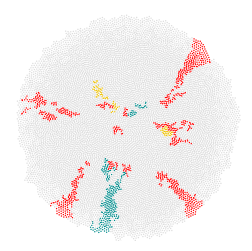

In [8]:
condition = 'Low Motility'; df = combined_data[condition]

selected_t = 240

plotting(
    data_plot=df,
    t=selected_t,
    size_max=2500,
)

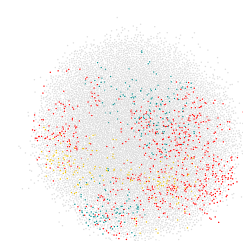

In [9]:
condition = 'High Motility'; df = combined_data[condition]

selected_t = 208

plotting(
    data_plot=df,
    t=selected_t,
    size_max=2500,
)

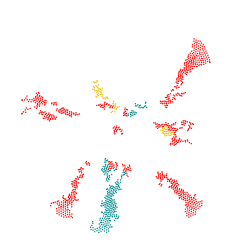

In [10]:
# one option is to only show subclones

condition = 'Low Motility'; df = combined_data[condition]

selected_t = 240

plotting(
    data_plot=df,
    t=selected_t,
    size_max=2500,
    show_subclones_only=True
)

### multiple time points

Note that tumours with higher intrinsic motility grows faster to reach a certain size.

For visualisation at comparable sizes, the following time points are selected
- low motility: 120, 168, 216, 240
- high motility: 120, 160, 188, 208

t = 120


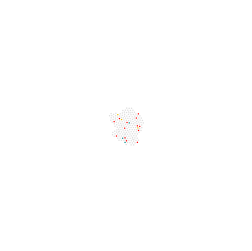

t = 168


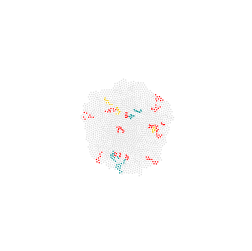

t = 216


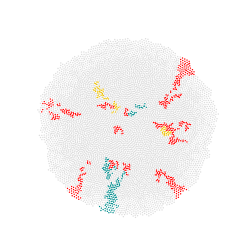

t = 240


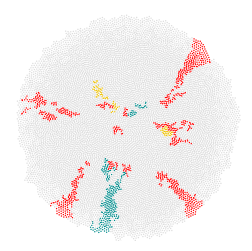

In [11]:
condition = 'Low Motility'; df = combined_data[condition]

selected_ts = [120, 168, 216, 240]

for selected_t in selected_ts:
    print(f"t = {selected_t}")
    plotting(
        data_plot=df,
        t=selected_t,
        size_max=2500,
    )

t = 120


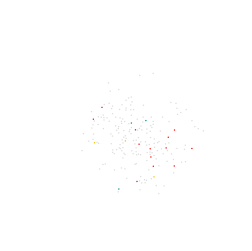

t = 160


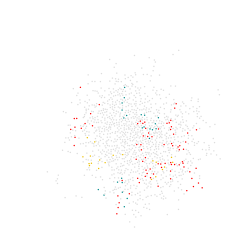

t = 188


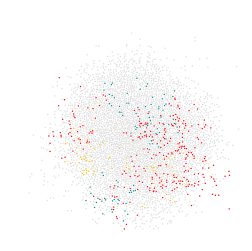

t = 208


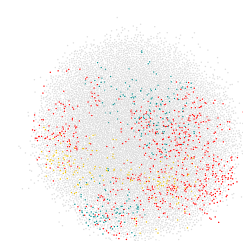

In [12]:
condition = 'High Motility'; df = combined_data[condition]

selected_ts = [120, 160, 188, 208]

for selected_t in selected_ts:
    print(f"t = {selected_t}")
    plotting(
        data_plot=df,
        t=selected_t,
        size_max=2500,
    )